##LogReg

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/axsos ass/stroke.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


In [6]:
df.describe()

,id,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,1137.000000,1137.000000,1137.000000,1137.000000,1085.000000,1137.000000
mean,36750.933157,0.118734,0.068602,107.664002,29.198065,0.120493
std,21112.281253,0.323617,0.252887,47.618723,7.669615,0.325680
min,77.000000,0.000000,0.000000,55.270000,11.300000,0.000000
25%,17986.000000,0.000000,0.000000,77.600000,24.100000,0.000000
50%,37479.000000,0.000000,0.000000,91.820000,28.500000,0.000000
75%,55410.000000,0.000000,0.000000,113.850000,33.200000,0.000000
max,72918.000000,1.000000,1.000000,266.590000,64.400000,1.000000


In [7]:
# Check missing values
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,52


In [8]:
# Check target balance
df['stroke'].value_counts(normalize=True)

,proportion
stroke,
0,0.879507
1,0.120493


In [9]:
# Separate features and target
X = df.drop(columns='stroke')
y = df['stroke']

In [10]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
# Preprocessing pipelines
cat_selector = make_column_selector(dtype_include='object')
num_selector = make_column_selector(dtype_include='number')

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

num_pipe = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', cat_pipe, cat_selector),
        ('numeric', num_pipe, num_selector)
    ],
    verbose_feature_names_out=False
)

In [12]:
# Default Logistic Regression model
logreg_pipe = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)

logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6bb2b40>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6859d90>)],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression(max_iter=1000))])

[[195   6]
 [ 27   0]]


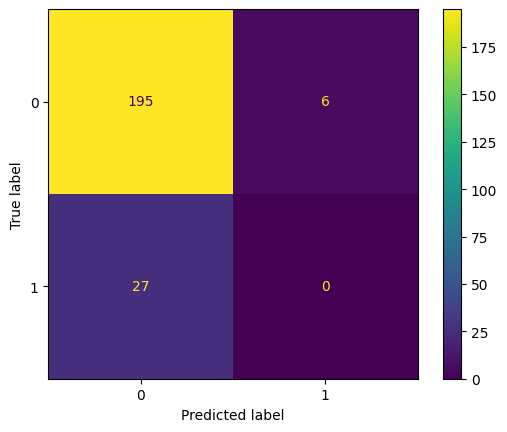

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       201
           1       0.00      0.00      0.00        27

    accuracy                           0.86       228
   macro avg       0.44      0.49      0.46       228
weighted avg       0.77      0.86      0.81       228



In [13]:
# Evaluate default model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_default = logreg_pipe.predict(X_test)

print(confusion_matrix(y_test, y_pred_default))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default)
plt.show()

print(classification_report(y_test, y_pred_default))

In [14]:
logreg_pipe = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

logreg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6bb2b40>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6859d90>)],
                                   verbose_feature_names_out=False)),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l2'],
    'logisticregression__solver': ['lbfgs'],
    'logisticregression__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    logreg_pipe,
    param_grid,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('categorical',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6bb2b40>),
                                                                        ('n...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6859d90>)],
                                                          verbose_feature_names_out=False)),
                                       ('logisticregression',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000))]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.001, 0.01, 0.1, 1, 10,
                                                   100],
                         'logisticregression__class_weight': [None, 'balanced'],
                         'logisticregression__penalty': ['l2'],
                         'logisticregression__solver': ['lbfgs']},
             scoring='recall_macro')

In [16]:
grid.best_params_

{'logisticregression__C': 100,
 'logisticregression__class_weight': 'balanced',
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'lbfgs'}

In [17]:
best_model = grid.best_estimator_

[[144  57]
 [  8  19]]


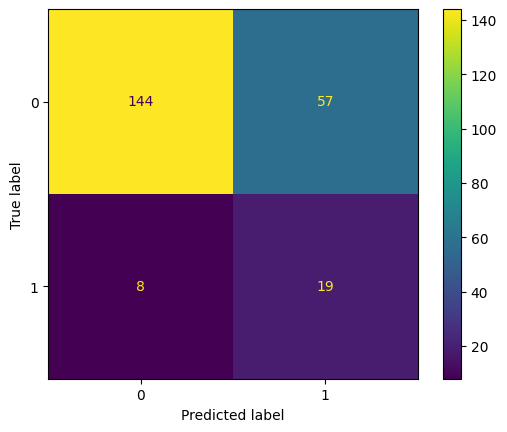

              precision    recall  f1-score   support

           0       0.95      0.72      0.82       201
           1       0.25      0.70      0.37        27

    accuracy                           0.71       228
   macro avg       0.60      0.71      0.59       228
weighted avg       0.86      0.71      0.76       228



In [18]:
y_pred_best = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_best))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.show()

print(classification_report(y_test, y_pred_best))

The best model used:

class_weight = 'balanced'

This model improved the recall for the stroke class significantly (from 0 to ~0.70), meaning it can correctly identify most stroke cases.
Although precision decreased, this is acceptable in medical applications where missing a positive case (false negative) is more critical than having false positives.

| Model   | Recall (stroke) | Comment |
| ------- | --------------- | ------- |
| Default | 0.00           | useless |
| Tuned   | 0.70           | useful  |


##KNN

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
# Default KNN model
knn_pipe = make_pipeline(
    preprocessor,
    KNeighborsClassifier()
)

knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6bb2b40>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6859d90>)],
                                   verbose_feature_names_out=False)),
                ('kneighborsclassifier', KNeighborsClassifier())])

[[195   6]
 [ 24   3]]


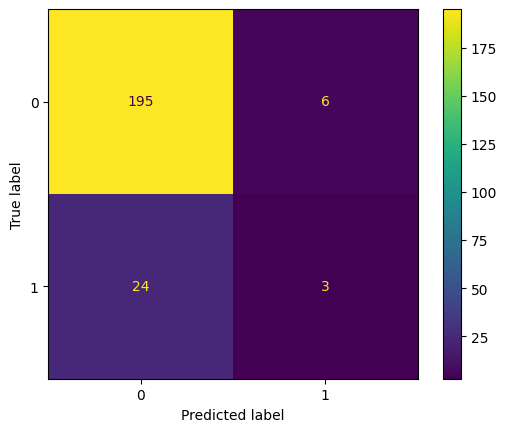

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       201
           1       0.33      0.11      0.17        27

    accuracy                           0.87       228
   macro avg       0.61      0.54      0.55       228
weighted avg       0.82      0.87      0.84       228



In [21]:
# Evaluate default KNN
y_pred_knn_default = knn_pipe.predict(X_test)

print(confusion_matrix(y_test, y_pred_knn_default))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_default)
plt.show()

print(classification_report(y_test, y_pred_knn_default))

In [22]:
# Tune KNN with GridSearchCV
knn_params = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__p': [1, 2]
}

knn_grid = GridSearchCV(
    knn_pipe,
    knn_params,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)

Fitting 3 folds for each of 28 candidates, totalling 84 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('categorical',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6bb2b40>),
                                                                        ('n...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6859d90>)],
                                                          verbose_feature_names_out=False)),
                                       ('kneighborsclassifier',
                                        KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11,
                                                               15, 21],
                         'kneighborsclassifier__p': [1, 2],
                         'kneighborsclassifier__weights': ['uniform',
                                                           'distance']},
             scoring='recall_macro', verbose=1)

In [23]:
# Best parameters
knn_grid.best_params_

{'kneighborsclassifier__n_neighbors': 3,
 'kneighborsclassifier__p': 2,
 'kneighborsclassifier__weights': 'distance'}

[[190  11]
 [ 25   2]]


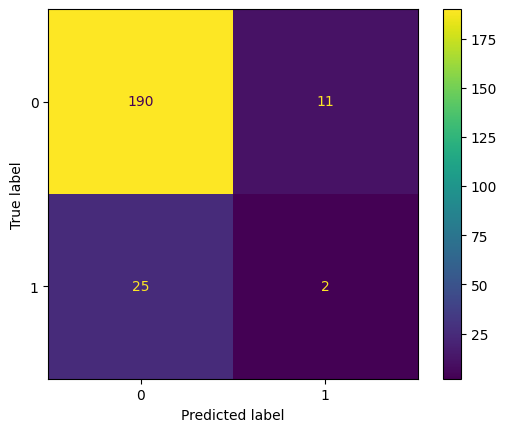

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       201
           1       0.15      0.07      0.10        27

    accuracy                           0.84       228
   macro avg       0.52      0.51      0.51       228
weighted avg       0.80      0.84      0.82       228



In [24]:
# Evaluate tuned KNN
best_knn = knn_grid.best_estimator_

y_pred_knn_tuned = best_knn.predict(X_test)

print(confusion_matrix(y_test, y_pred_knn_tuned))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_tuned)
plt.show()

print(classification_report(y_test, y_pred_knn_tuned))

The best hyperparameters were obtained using GridSearchCV (mention knn_grid.best_params_), but even after tuning, the model did not improve significantly.

Model evaluation:

The KNN model performed poorly on the stroke class, with recall values close to zero. This indicates that the model failed to correctly identify most stroke cases.

Comparison with Logistic Regression:

Compared to Logistic Regression, KNN performed significantly worse. Logistic Regression achieved a much higher recall (~0.70), making it more suitable for this medical classification problem.

KNN is not suitable for this dataset due to class imbalance and its sensitivity to majority class dominance.

##Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6bb2b40>),
                                                 ('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6859d90>)],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

Evaluate Default Mode

[[200   1]
 [ 27   0]]


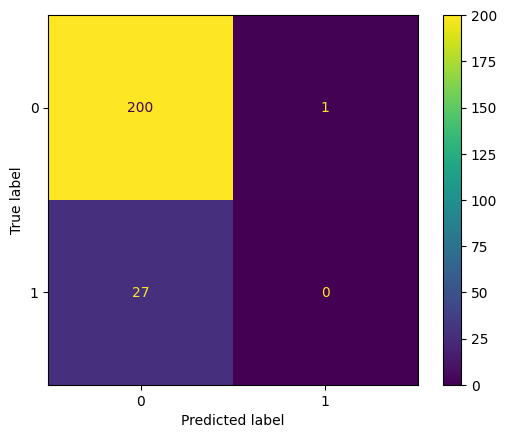

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       201
           1       0.00      0.00      0.00        27

    accuracy                           0.88       228
   macro avg       0.44      0.50      0.47       228
weighted avg       0.78      0.88      0.82       228



In [28]:
y_pred_rf_default = rf_pipe.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf_default))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_default)
plt.show()

print(classification_report(y_test, y_pred_rf_default))

GridSearchCV

In [29]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [None, 5, 10],
    'randomforestclassifier__min_samples_split': [2, 5],
    'randomforestclassifier__class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('categorical',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7fa3d6bb2b40>),
                                                                        ('n...
                                                          verbose_feature_names_out=False)),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__class_weight': [None,
                                                                  'balanced'],
                         'randomforestclassifier__max_depth': [None, 5, 10],
                         'randomforestclassifier__min_samples_split': [2, 5],
                         'randomforestclassifier__n_estimators': [100, 200]},
             scoring='recall_macro', verbose=1)

In [30]:
rf_grid.best_params_

{'randomforestclassifier__class_weight': 'balanced',
 'randomforestclassifier__max_depth': 5,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__n_estimators': 200}

In [31]:
best_rf = rf_grid.best_estimator_

Evaluate Tuned Model

[[155  46]
 [  9  18]]


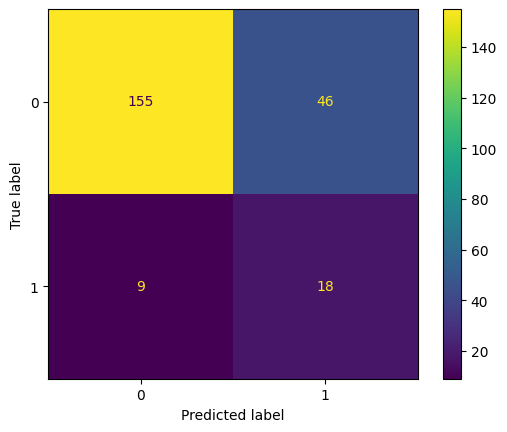

              precision    recall  f1-score   support

           0       0.95      0.77      0.85       201
           1       0.28      0.67      0.40        27

    accuracy                           0.76       228
   macro avg       0.61      0.72      0.62       228
weighted avg       0.87      0.76      0.80       228



In [32]:
y_pred_rf_tuned = best_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf_tuned))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_tuned)
plt.show()

print(classification_report(y_test, y_pred_rf_tuned))

class_weight = balanced

max_depth = 5

min_samples_split = 5

n_estimators = 200

recall (stroke) = 0.67

| Model               | Recall (stroke) | Accuracy | Verdict   |
| ------------------- | --------------- | -------- | --------- |
| Logistic Regression | 0.70            | 0.71     |  Best    |
| Random Forest       | 0.67            | 0.76     | Very good |
| KNN                 | 0.07            | 0.84     |  Useless |



I would recommend the Logistic Regression model for production. The main metric I used to make this decision was recall for the stroke class, because in medical applications it is critical to correctly identify as many positive cases as possible. Logistic Regression achieved the highest recall (around 0.70), meaning it was able to detect most stroke cases. Although Random Forest performed similarly, Logistic Regression had slightly better recall, making it more reliable for this task. I also considered overall model stability and simplicity, which further supports choosing Logistic Regression as the final model.